# RouteZone — Notebook 05 : Modélisation V1

---

| | |
|---|---|
| **Candidate** | Meriem Abdelouahed |
| **Formation** | Développeur en Intelligence Artificielle — Simplon x Microsoft |
| **Certification** | RNCP37827 |
| **Projet** | RouteZone — Prédiction de gravité des accidents routiers |
| **Notebook** | 05 / 08 — Modélisation V1 (baseline) |

---

## Sommaire

1. [Imports](#1-imports)
2. [Chargement des données](#2-chargement)
3. [Distribution de la variable cible originale](#3-distribution)
4. [Binarisation de la variable cible](#4-binarisation)
5. [Analyse des features](#5-features)
6. [Preprocessing](#6-preprocessing)
7. [Split aléatoire — détection data leakage](#7-split)
8. [Modèle 1 — Random Forest](#8-rf)
9. [Modèle 2 — XGBoost](#9-xgb)
10. [Modèle 3 — LightGBM](#10-lgbm)
11. [Comparaison des 3 modèles — split aléatoire](#11-comparaison)
12. [Correction — Split temporel](#12-split-temporel)
13. [Comparaison split aléatoire vs split temporel](#13-comparaison-splits)
14. [Gestion du déséquilibre des classes](#14-desequilibre)
15. [Sauvegarde du meilleur modèle](#15-sauvegarde)
16. [Bilan](#16-bilan)

---

> **Objectif :** prédire si un accident est **GRAVE** ou **PAS GRAVE**
> à partir des données BAAC 2022-2024.
>
> **Variable cible binaire :**
> - 0 = Pas grave (Indemne ou Blessé léger)
> - 1 = Grave (Tué ou Hospitalisé)
>
> **Modèles testés :** Random Forest · XGBoost · LightGBM
>
> **Métrique prioritaire :** Recall GRAVE — rater un accident grave est médicalement inacceptable.

<a id='1-imports'></a>
## 1. Imports

---

In [1]:
# ── Imports centralisés ──────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score,
    accuracy_score, recall_score, roc_auc_score, precision_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Imports OK')

Imports OK


<a id='2-chargement'></a>
## 2. Chargement des données

---

In [2]:
DATA_CLEAN    = Path('../data/processed/dataset_clean.csv')
DATA_ENRICHED = Path('../data/processed/dataset_enriched.csv')
MODELS_DIR    = Path('../models')
VIZ_DIR       = Path('./visualisations')
MODELS_DIR.mkdir(exist_ok=True)
VIZ_DIR.mkdir(exist_ok=True)

if DATA_ENRICHED.exists():
    df = pd.read_csv(DATA_ENRICHED)
    print('Dataset ENRICHI chargé (avec colonnes météo)')
else:
    df = pd.read_csv(DATA_CLEAN)
    print('Dataset CLEAN chargé')

print(f'Lignes   : {len(df):,}')
print(f'Colonnes : {df.shape[1]}')

Dataset ENRICHI chargé (avec colonnes météo)
Lignes   : 413,570
Colonnes : 48


<a id='3-distribution'></a>
## 3. Distribution de la variable cible originale `grav`

---

> On regarde d'abord la distribution des 4 classes originales
> pour comprendre pourquoi la binarisation est nécessaire.

Distribution originale de grav (4 classes) :
  Indemne         :  173,340 (41.9%)
  Tué             :   10,456 (2.5%)
  Hospitalisé     :   61,667 (14.9%)
  Blessé léger    :  168,107 (40.6%)


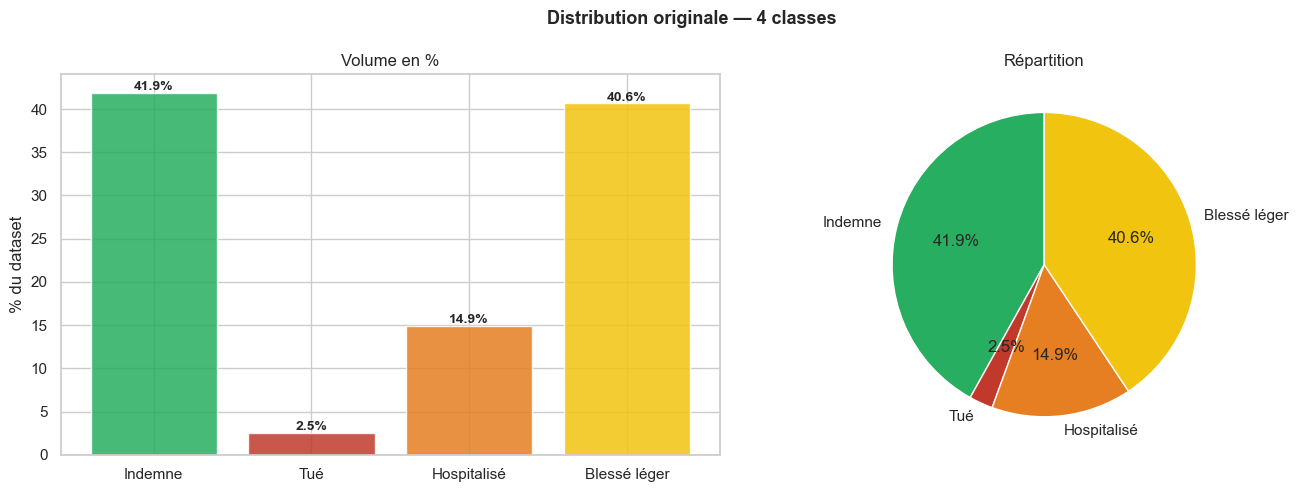

In [3]:
labels_grav = {1: 'Indemne', 2: 'Tué', 3: 'Hospitalisé', 4: 'Blessé léger'}
couleurs    = {1: '#27ae60', 2: '#c0392b', 3: '#e67e22', 4: '#f1c40f'}
counts      = df['grav'].value_counts().sort_index()
counts_pct  = counts / counts.sum() * 100

print('Distribution originale de grav (4 classes) :')
for i in counts.index:
    print(f'  {labels_grav[i]:<15} : {counts[i]:>8,} ({counts_pct[i]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution originale — 4 classes', fontsize=13, fontweight='bold')

barres = axes[0].bar(
    [labels_grav[i] for i in counts.index],
    counts_pct.values,
    color=[couleurs[i] for i in counts.index],
    edgecolor='white', alpha=0.85
)
axes[0].set_title('Volume en %')
axes[0].set_ylabel('% du dataset')
for bar, val in zip(barres, counts_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(counts_pct.values,
            labels=[labels_grav[i] for i in counts.index],
            colors=[couleurs[i] for i in counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_01_distribution_4classes.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - Les **Tués** ne représentent que ~2.5% du dataset — classe extrêmement rare
> - Les **Hospitalisés** représentent ~15% — également minoritaires
> - Ce fort déséquilibre explique pourquoi les modèles à 4 classes donnaient un F1 macro ~0.50
> - **Décision :** binariser la variable cible avant tout preprocessing

<a id='4-binarisation'></a>
## 4. Binarisation de la variable cible

---

### Pourquoi regrouper les 4 classes en 2 ?

**Problème avec 4 classes :** Les modèles testés sur 4 classes ont donné un F1 macro ~0.50.
La classe Tués (2.5%) est trop rare pour être apprise correctement.

**Solution — regroupement selon l'impact médical réel :**
- **GRAVE (1)** = Tué + Hospitalisé → nécessite une intervention médicale urgente
- **PAS GRAVE (0)** = Indemne + Blessé léger → pas d'hospitalisation nécessaire

**Justification médicale :** La vraie question opérationnelle : *"Faut-il envoyer des secours d'urgence ?"*

> **Important :** la binarisation se fait ICI, AVANT le split train/test et AVANT le preprocessing.

Distribution après binarisation (2 classes) :
  Pas grave    :  341,447 (82.6%)
  Grave        :   72,123 (17.4%)


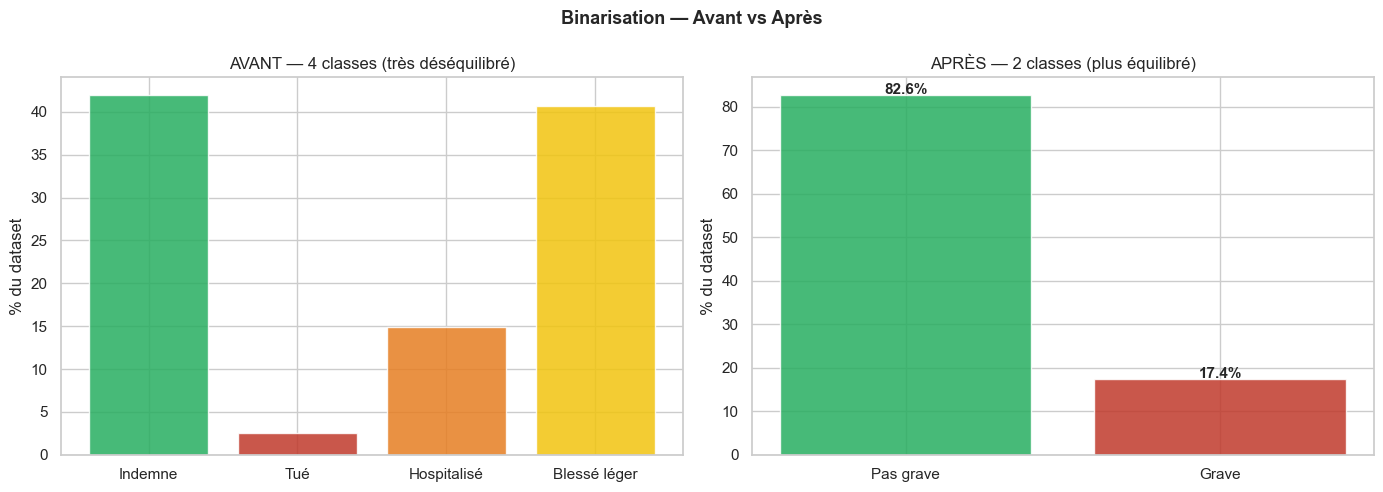

In [4]:
# Binarisation de grav — AVANT tout split
# GRAVE (1)     = Tué (grav=2) ou Hospitalisé (grav=3)
# PAS GRAVE (0) = Indemne (grav=1) ou Blessé léger (grav=4)
df['grav_bin'] = df['grav'].apply(lambda x: 1 if x in [2, 3] else 0)

counts_bin     = df['grav_bin'].value_counts().sort_index()
counts_bin_pct = counts_bin / counts_bin.sum() * 100

print('Distribution après binarisation (2 classes) :')
labels_bin = {0: 'Pas grave', 1: 'Grave'}
for i in counts_bin.index:
    print(f'  {labels_bin[i]:<12} : {counts_bin[i]:>8,} ({counts_bin_pct[i]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Binarisation — Avant vs Après', fontsize=13, fontweight='bold')

axes[0].bar([labels_grav[i] for i in counts.index], counts_pct.values,
            color=[couleurs[i] for i in counts.index], edgecolor='white', alpha=0.85)
axes[0].set_title('AVANT — 4 classes (très déséquilibré)')
axes[0].set_ylabel('% du dataset')

axes[1].bar(['Pas grave', 'Grave'], counts_bin_pct.values,
            color=['#27ae60', '#c0392b'], edgecolor='white', alpha=0.85)
axes[1].set_title('APRÈS — 2 classes (plus équilibré)')
axes[1].set_ylabel('% du dataset')
for bar, val in zip(axes[1].patches, counts_bin_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_02_binarisation.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - **Avant :** Tués à 2.5% → quasi invisible pour les modèles
> - **Après :** GRAVE à ~17% vs PAS GRAVE à ~83% → déséquilibre gérable
> - Le regroupement est cohérent médicalement et améliore les performances

<a id='5-features'></a>
## 5. Analyse des features disponibles

---

In [5]:
nan_pct = df.isnull().mean() * 100
print('Colonnes et % de NaN (triées) :')
print(nan_pct.sort_values(ascending=False).to_string())

Colonnes et % de NaN (triées) :
weathercode      90.323041
windspeed        90.323041
precipitation    90.323041
temperature      90.323041
Num_Acc           0.000000
obs               0.000000
catu              0.000000
grav              0.000000
sexe              0.000000
an_nais           0.000000
trajet            0.000000
secu1             0.000000
senc              0.000000
catv              0.000000
choc              0.000000
obsm              0.000000
id_vehicule       0.000000
manv              0.000000
motor             0.000000
age               0.000000
heure             0.000000
jour_semaine      0.000000
weekend           0.000000
place             0.000000
id_usager         0.000000
jour              0.000000
vma               0.000000
mois              0.000000
an                0.000000
hrmn              0.000000
lum               0.000000
dep               0.000000
agg               0.000000
int               0.000000
atm               0.000000
col               0.000

> **Observations :**
> - On écarte les colonnes identifiants (`Num_Acc`, `id_usager`, `id_vehicule`) — sans valeur prédictive
> - On écarte `lat` et `long` — déjà capturés par `dep` et `agg`
> - On écarte `hrmn` (format texte) — on a `heure` (entier 0-23)
> - On écarte `an_nais` — on a `age` calculé
> - On garde les colonnes météo si disponibles

In [6]:
features = [
    'lum', 'agg', 'int', 'atm', 'col',
    'catr', 'circ', 'vosp', 'prof', 'plan', 'surf', 'infra', 'situ', 'vma',
    'catu', 'sexe', 'trajet', 'secu1',
    'catv',
    'age', 'heure', 'mois',
]

for col in ['temperature', 'precipitation', 'windspeed']:
    if col in df.columns:
        features.append(col)
        print(f'Feature météo ajoutée : {col}')

print(f'\n{len(features)} features sélectionnées')

Feature météo ajoutée : temperature
Feature météo ajoutée : precipitation
Feature météo ajoutée : windspeed

25 features sélectionnées


<a id='6-preprocessing'></a>
## 6. Preprocessing

---

In [7]:
df_model = df[features + ['grav_bin', 'an']].dropna(subset=['grav_bin']).copy()

X = df_model[features].copy()
y = df_model['grav_bin']

for col in X.columns:
    if X[col].isnull().any():
        if X[col].dtype in ['float64', 'int64']:
            X[col] = X[col].fillna(X[col].median())
        else:
            X[col] = X[col].fillna(X[col].mode()[0])

X = X.astype(float)

print(f'X : {X.shape[0]:,} lignes | {X.shape[1]} features')
print(f'NaN restants dans X : {X.isnull().sum().sum()}')
print(f'\nDistribution de y :')
for val, nb in y.value_counts().sort_index().items():
    print(f'  {val} ({["Pas grave","Grave"][val]:<10}) : {nb:>8,} ({nb/len(y)*100:.1f}%)')

X : 413,570 lignes | 25 features
NaN restants dans X : 0

Distribution de y :
  0 (Pas grave ) :  341,447 (82.6%)
  1 (Grave     ) :   72,123 (17.4%)


> **Observations :**
> - Zéro NaN dans X — le dataset est propre pour la modélisation
> - On garde la colonne `an` dans `df_model` pour la détection du data leakage à l'étape suivante
> - Le preprocessing ne touche qu'aux features X, jamais à y

<a id='7-split'></a>
## 7. Split aléatoire — détection data leakage

---

> - **Train (70%)** → le modèle apprend sur ces données
> - **Validation (15%)** → on compare les modèles sans toucher au test
> - **Test (15%)** → score final, utilisé une seule fois à la toute fin
>
> `stratify=y` garantit la même proportion GRAVE/PAS GRAVE dans chaque partie.

In [8]:
# Split aléatoire — méthode classique
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f'Train      : {len(X_train):,} lignes ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validation : {len(X_val):,}  lignes ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test       : {len(X_test):,}  lignes ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nDistribution GRAVE dans le train : {y_train.mean()*100:.1f}%')
print(f'Distribution GRAVE dans le test  : {y_test.mean()*100:.1f}%')

Train      : 289,664 lignes (70%)
Validation : 61,870  lignes (15%)
Test       : 62,036  lignes (15%)

Distribution GRAVE dans le train : 17.4%
Distribution GRAVE dans le test  : 17.4%


> **Observations :**
> - Le split stratifié garantit la même proportion de GRAVE dans chaque partie
> - On vérifie maintenant quelles années sont dans le train et dans le test

In [9]:
# ── Détection du data leakage ────────────────────────────────────
# Si le train et le test contiennent les mêmes années,
# le modèle a vu des données futures pendant l'entraînement

annees_train = sorted(df_model.loc[X_train.index, 'an'].unique())
annees_test  = sorted(df_model.loc[X_test.index,  'an'].unique())

print('Années dans le TRAIN :', annees_train)
print('Années dans le TEST  :', annees_test)
print('Années en commun     :', sorted(set(annees_train) & set(annees_test)))

Années dans le TRAIN : [2022, 2023, 2024]
Années dans le TEST  : [2022, 2023, 2024]
Années en commun     : [2022, 2023, 2024]


> **Observation — Data leakage détecté :**
>
> Le train et le test contiennent exactement les mêmes années : 2022, 2023 et 2024.
> Cela signifie que le modèle a vu des accidents de 2024 pendant l'entraînement
> et qu'il est évalué sur des données de la même période.
>
> Les métriques obtenues avec ce split sont donc probablement surestimées —
> le modèle n'est pas évalué sur des données vraiment inconnues.
>
> On continue quand même sur ce split pour avoir une baseline à comparer.

<a id='8-rf'></a>
## 8. Modèle 1 — Random Forest

---

> **C'est quoi Random Forest ?**
> Une forêt aléatoire = plusieurs centaines d'arbres de décision entraînés
> en parallèle sur des sous-échantillons aléatoires des données.
> Chaque arbre vote pour Grave ou Pas grave, la majorité l'emporte.
>
> **`class_weight='balanced'`** : donne automatiquement plus de poids
> à la classe GRAVE (minoritaire) pour que le modèle ne l'ignore pas.

In [10]:
mlflow.set_experiment('RouteZone_Modelisation_Binaire')
labels = ['Pas grave', 'Grave']

with mlflow.start_run(run_name='Random_Forest'):
    params_rf = {
        'n_estimators': 200, 'max_depth': 15,
        'min_samples_split': 10, 'class_weight': 'balanced',
        'random_state': 42, 'n_jobs': -1
    }
    mlflow.log_params(params_rf)
    print('Entraînement Random Forest...')
    rf = RandomForestClassifier(**params_rf)
    rf.fit(X_train, y_train)

    y_pred_val_rf = rf.predict(X_val)
    f1m_val_rf    = f1_score(y_val, y_pred_val_rf, average='macro')
    y_pred_rf     = rf.predict(X_test)
    y_proba_rf    = rf.predict_proba(X_test)[:, 1]
    acc_rf  = accuracy_score(y_test, y_pred_rf)
    f1m_rf  = f1_score(y_test, y_pred_rf, average='macro')
    auc_rf  = roc_auc_score(y_test, y_proba_rf)
    rec_rf  = recall_score(y_test, y_pred_rf, pos_label=1)

    mlflow.log_metric('f1_macro_val',  f1m_val_rf)
    mlflow.log_metric('f1_macro_test', f1m_rf)
    mlflow.log_metric('auc_roc',       auc_rf)
    mlflow.log_metric('recall_grave',  rec_rf)
    mlflow.sklearn.log_model(rf, 'random_forest')

    print(f'  F1 macro val  : {f1m_val_rf:.4f}')
    print(f'  F1 macro test : {f1m_rf:.4f}')
    print(f'  AUC-ROC       : {auc_rf:.4f}')
    print(f'  Recall GRAVE  : {rec_rf:.4f}')

Entraînement Random Forest...


2026/06/10 23:40:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 23:41:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  F1 macro val  : 0.7050
  F1 macro test : 0.7064
  AUC-ROC       : 0.8561
  Recall GRAVE  : 0.7374


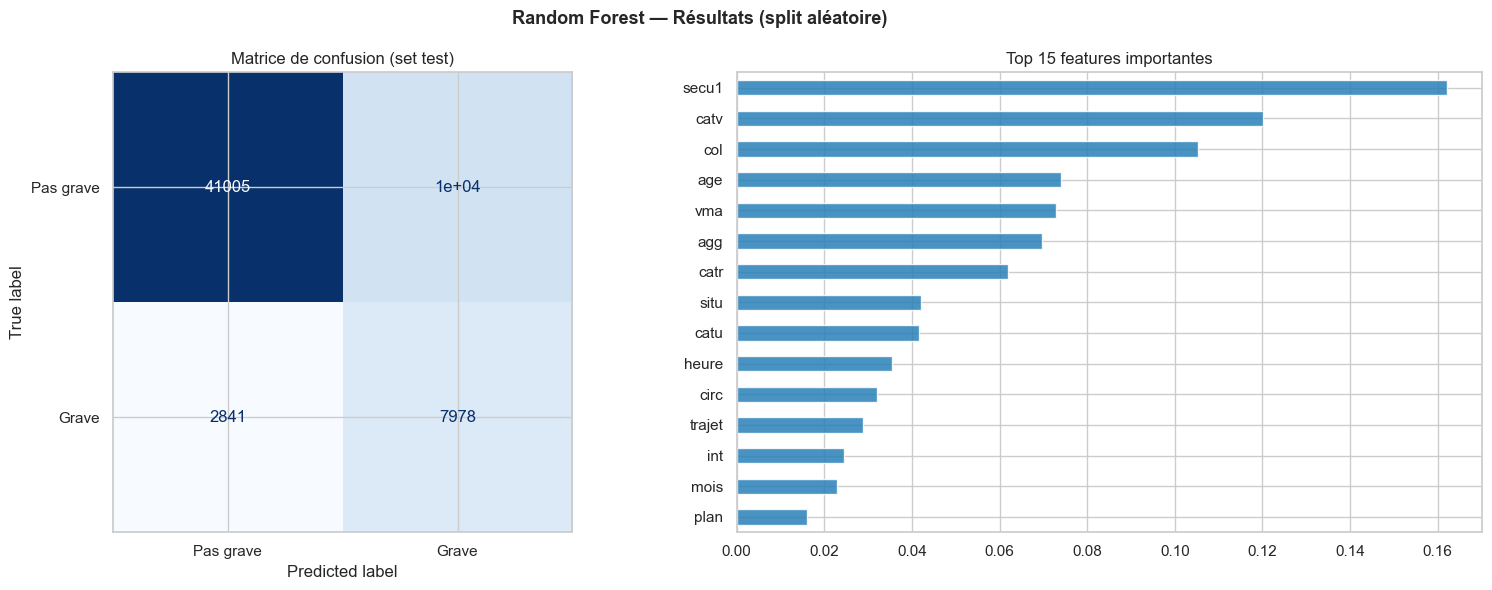

              precision    recall  f1-score   support

   Pas grave       0.94      0.80      0.86     51217
       Grave       0.44      0.74      0.55     10819

    accuracy                           0.79     62036
   macro avg       0.69      0.77      0.71     62036
weighted avg       0.85      0.79      0.81     62036



In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Résultats (split aléatoire)', fontsize=13, fontweight='bold')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=labels).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de confusion (set test)')

importances_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True).tail(15)
importances_rf.plot(kind='barh', ax=axes[1], color='#2980b9', alpha=0.85)
axes[1].set_title('Top 15 features importantes')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_03_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred_rf, target_names=labels))

> **Observations :**
> - La matrice de confusion : ligne = vraie classe, colonne = classe prédite
> - Un bon modèle a de gros chiffres sur la diagonale (vrais positifs et vrais négatifs)
> - Le Recall GRAVE est la métrique la plus importante — rater un accident grave est dangereux
> - Les features en haut du graphique influencent le plus la prédiction

<a id='9-xgb'></a>
## 9. Modèle 2 — XGBoost

---

> Chaque arbre corrige les erreurs du précédent (boosting séquentiel).
> `scale_pos_weight` est l'équivalent de `class_weight='balanced'` pour XGBoost —
> on lui dit combien la classe GRAVE est rare.

In [12]:
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight : {scale:.2f} (PAS GRAVE / GRAVE dans le train)')

scale_pos_weight : 4.73 (PAS GRAVE / GRAVE dans le train)


In [13]:
with mlflow.start_run(run_name='XGBoost'):
    params_xgb = {
        'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'scale_pos_weight': scale, 'eval_metric': 'logloss',
        'random_state': 42, 'n_jobs': -1
    }
    mlflow.log_params(params_xgb)
    print('Entraînement XGBoost...')
    xgb = XGBClassifier(**params_xgb)
    xgb.fit(X_train, y_train)

    y_pred_val_xgb = xgb.predict(X_val)
    f1m_val_xgb    = f1_score(y_val, y_pred_val_xgb, average='macro')
    y_pred_xgb     = xgb.predict(X_test)
    y_proba_xgb    = xgb.predict_proba(X_test)[:, 1]
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    f1m_xgb = f1_score(y_test, y_pred_xgb, average='macro')
    auc_xgb = roc_auc_score(y_test, y_proba_xgb)
    rec_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)

    mlflow.log_metric('f1_macro_val',  f1m_val_xgb)
    mlflow.log_metric('f1_macro_test', f1m_xgb)
    mlflow.log_metric('auc_roc',       auc_xgb)
    mlflow.log_metric('recall_grave',  rec_xgb)
    mlflow.sklearn.log_model(xgb, 'xgboost')

    print(f'  F1 macro val  : {f1m_val_xgb:.4f}')
    print(f'  F1 macro test : {f1m_xgb:.4f}')
    print(f'  AUC-ROC       : {auc_xgb:.4f}')
    print(f'  Recall GRAVE  : {rec_xgb:.4f}')

Entraînement XGBoost...


2026/06/10 23:41:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 23:41:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  F1 macro val  : 0.6999
  F1 macro test : 0.7026
  AUC-ROC       : 0.8622
  Recall GRAVE  : 0.7818


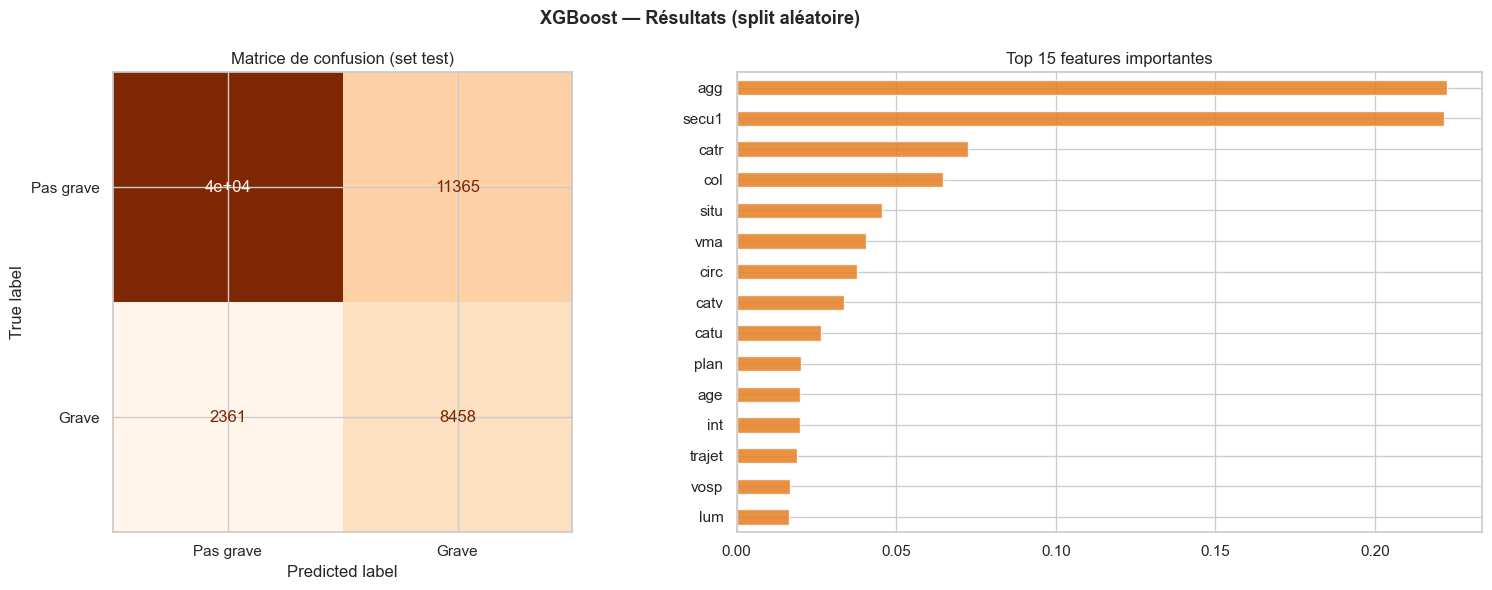

              precision    recall  f1-score   support

   Pas grave       0.94      0.78      0.85     51217
       Grave       0.43      0.78      0.55     10819

    accuracy                           0.78     62036
   macro avg       0.69      0.78      0.70     62036
weighted avg       0.85      0.78      0.80     62036



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost — Résultats (split aléatoire)', fontsize=13, fontweight='bold')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=labels).plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title('Matrice de confusion (set test)')

importances_xgb = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True).tail(15)
importances_xgb.plot(kind='barh', ax=axes[1], color='#e67e22', alpha=0.85)
axes[1].set_title('Top 15 features importantes')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_04_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred_xgb, target_names=labels))

> **Observations :**
> - Comparer l'AUC-ROC avec Random Forest — lequel distingue mieux GRAVE de PAS GRAVE ?
> - Le `scale_pos_weight` aide XGBoost à mieux détecter les accidents GRAVE
> - Regarder si les features importantes sont cohérentes avec Random Forest

<a id='10-lgbm'></a>
## 10. Modèle 3 — LightGBM

---

> Le plus rapide des 3 — construction feuille par feuille (leaf-wise).
> `class_weight='balanced'` gère nativement le déséquilibre des classes.

In [15]:
with mlflow.start_run(run_name='LightGBM'):
    params_lgbm = {
        'n_estimators': 200, 'max_depth': 10, 
        'learning_rate': 0.1,
        'num_leaves': 63, 'subsample': 0.8, 
        'colsample_bytree': 0.8,
        'class_weight': 'balanced', 'random_state': 42,
        'n_jobs': -1, 'verbose': -1
    }
    mlflow.log_params(params_lgbm)
    print('Entraînement LightGBM...')
    lgbm = LGBMClassifier(**params_lgbm)
    lgbm.fit(X_train, y_train)

    y_pred_val_lgbm = lgbm.predict(X_val)
    f1m_val_lgbm    = f1_score(y_val, y_pred_val_lgbm, average='macro')
    y_pred_lgbm     = lgbm.predict(X_test)
    y_proba_lgbm    = lgbm.predict_proba(X_test)[:, 1]
    acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
    f1m_lgbm = f1_score(y_test, y_pred_lgbm, average='macro')
    auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)
    rec_lgbm = recall_score(y_test, y_pred_lgbm, pos_label=1)

    mlflow.log_metric('f1_macro_val',  f1m_val_lgbm)
    mlflow.log_metric('f1_macro_test', f1m_lgbm)
    mlflow.log_metric('auc_roc',       auc_lgbm)
    mlflow.log_metric('recall_grave',  rec_lgbm)
    mlflow.sklearn.log_model(lgbm, 'lightgbm')

    print(f'  F1 macro val  : {f1m_val_lgbm:.4f}')
    print(f'  F1 macro test : {f1m_lgbm:.4f}')
    print(f'  AUC-ROC       : {auc_lgbm:.4f}')
    print(f'  Recall GRAVE  : {rec_lgbm:.4f}')

Entraînement LightGBM...


2026/06/10 23:42:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 23:42:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  F1 macro val  : 0.6905
  F1 macro test : 0.6947
  AUC-ROC       : 0.8599
  Recall GRAVE  : 0.7960


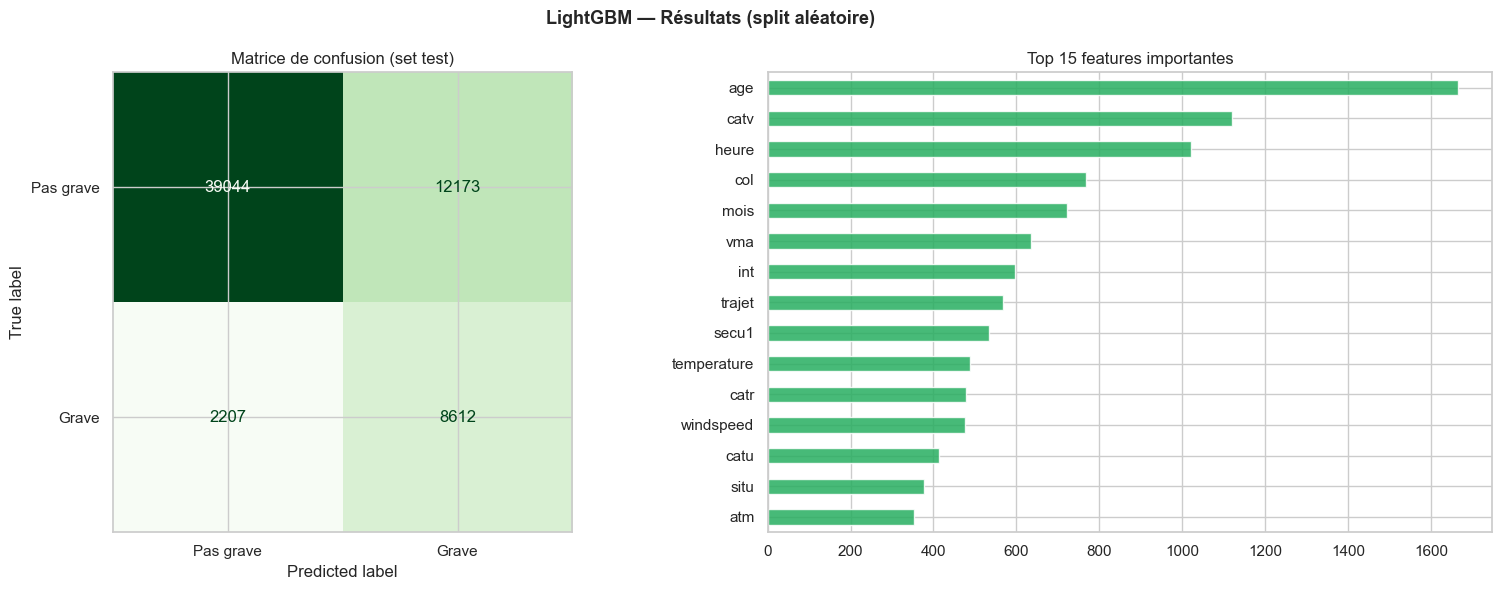

              precision    recall  f1-score   support

   Pas grave       0.95      0.76      0.84     51217
       Grave       0.41      0.80      0.54     10819

    accuracy                           0.77     62036
   macro avg       0.68      0.78      0.69     62036
weighted avg       0.85      0.77      0.79     62036



In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM — Résultats (split aléatoire)', fontsize=13, fontweight='bold')

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
ConfusionMatrixDisplay(cm_lgbm, display_labels=labels).plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Matrice de confusion (set test)')

importances_lgbm = pd.Series(lgbm.feature_importances_, index=features).sort_values(ascending=True).tail(15)
importances_lgbm.plot(kind='barh', ax=axes[1], color='#27ae60', alpha=0.85)
axes[1].set_title('Top 15 features importantes')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_05_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred_lgbm, target_names=labels))

> **Observations :**
> - LightGBM est souvent meilleur sur les données déséquilibrées grâce à `class_weight='balanced'`
> - Comparer son recall GRAVE avec les deux autres — c'est notre critère médical clé
> - L'AUC-ROC permet de comparer les 3 modèles sur une même échelle indépendante du seuil

Random Forest  Recall GRAVE : train=0.845  val=0.724  ecart=+0.121
XGBoost        Recall GRAVE : train=0.864  val=0.769  ecart=+0.095
LightGBM       Recall GRAVE : train=0.837  val=0.789  ecart=+0.048
Random Forest  F1 macro     : train=0.764  val=0.707  ecart=+0.057
XGBoost        F1 macro     : train=0.747  val=0.701  ecart=+0.045
LightGBM       F1 macro     : train=0.714  val=0.692  ecart=+0.022


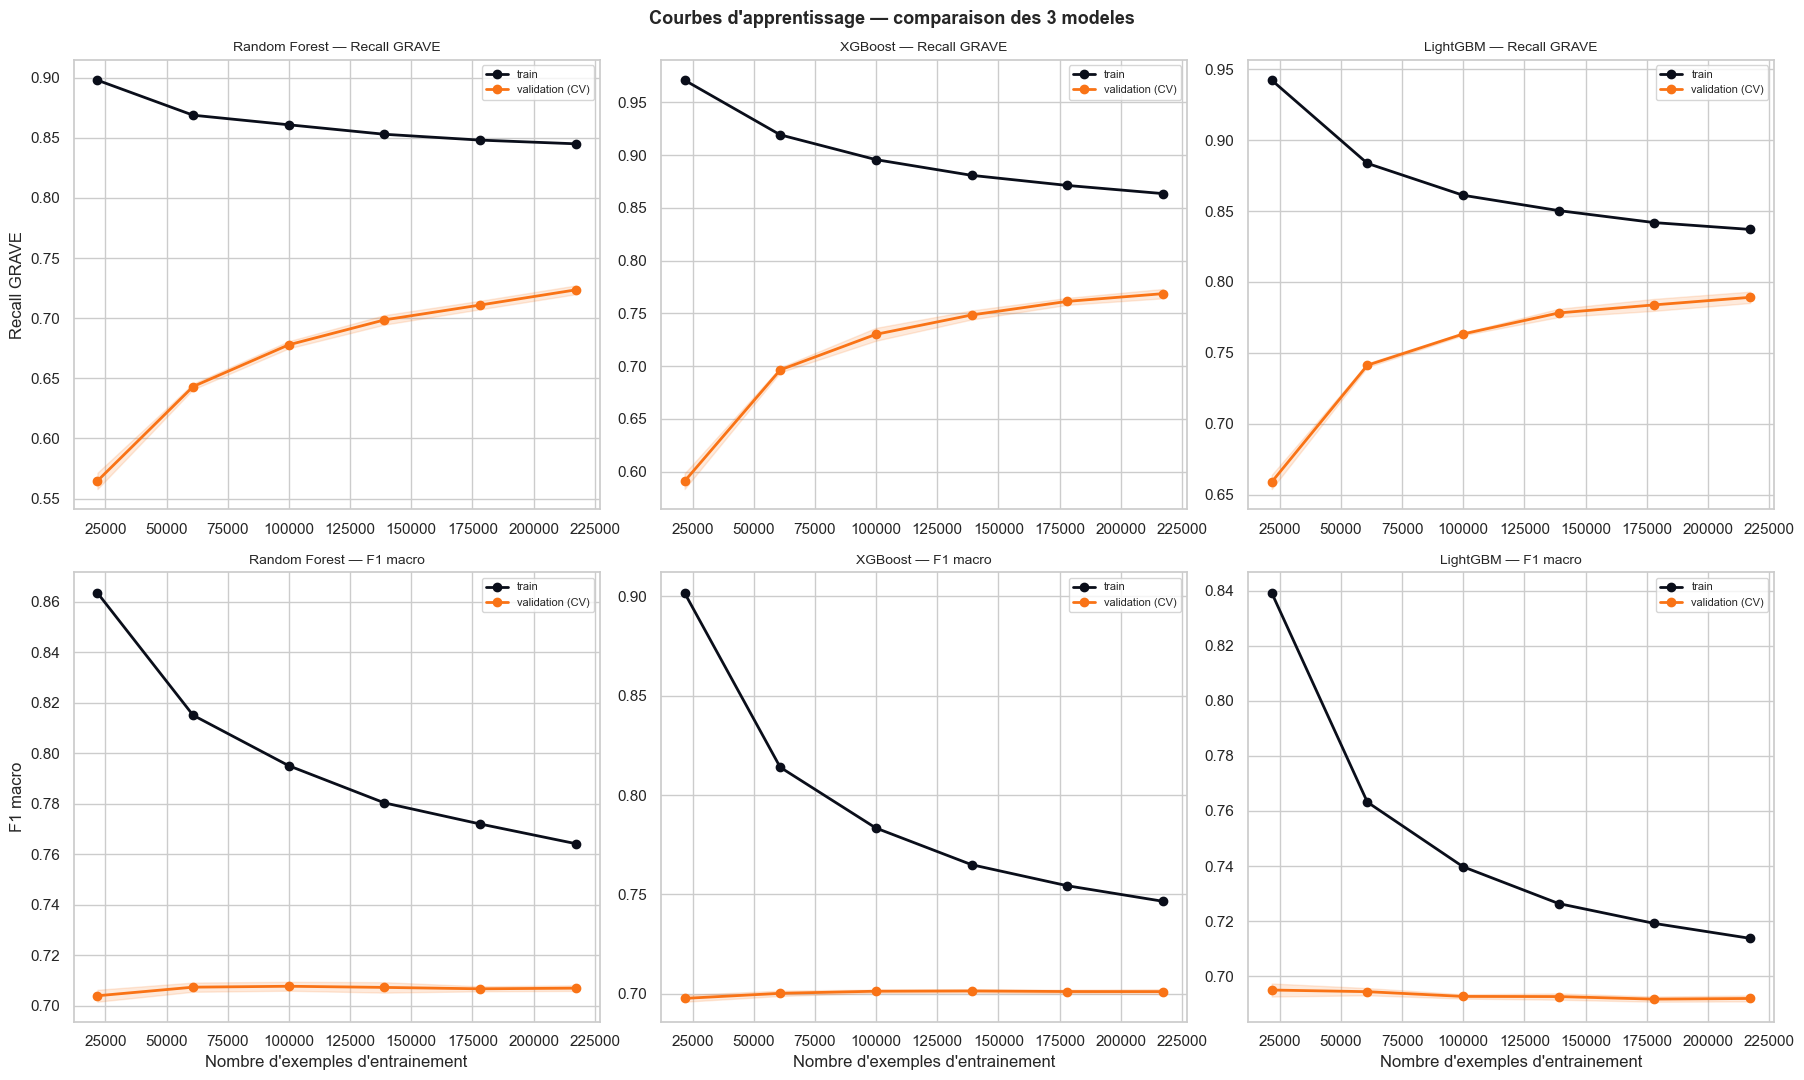

In [17]:
# ── Courbes d'apprentissage — les 3 modeles compares ─────────────
import numpy as np
from sklearn.model_selection import learning_curve, StratifiedKFold

ORANGE, NUIT = "#F97316", "#0A0E1A"
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# scale_pos_weight pour XGBoost (recalcule au cas ou)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

modeles = [
    ("Random Forest", RandomForestClassifier(**params_rf)),
    ("XGBoost",       XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                                    subsample=0.8, colsample_bytree=0.8,
                                    scale_pos_weight=scale_pos, eval_metric="logloss",
                                    random_state=42, n_jobs=-1)),
    ("LightGBM",      LGBMClassifier(**params_lgbm)),
]
metriques = [("recall", "Recall GRAVE"), ("f1_macro", "F1 macro")]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Courbes d'apprentissage — comparaison des 3 modeles",
             fontsize=13, fontweight="bold")

for r, (sc, titre_m) in enumerate(metriques):
    for c, (nom, est) in enumerate(modeles):
        ax = axes[r, c]
        sizes, tr, va = learning_curve(
            est, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 6),
            cv=cv, scoring=sc, n_jobs=-1, shuffle=True, random_state=42)
        ax.plot(sizes, tr.mean(1), "o-", color=NUIT, lw=2, label="train")
        ax.plot(sizes, va.mean(1), "o-", color=ORANGE, lw=2, label="validation (CV)")
        ax.fill_between(sizes, va.mean(1) - va.std(1), va.mean(1) + va.std(1),
                        color=ORANGE, alpha=0.15)
        ax.set_title(f"{nom} — {titre_m}", fontsize=10)
        if r == 1: ax.set_xlabel("Nombre d'exemples d'entrainement")
        if c == 0: ax.set_ylabel(titre_m)
        ax.legend(loc="best", fontsize=8)
        print(f"{nom:<14} {titre_m:<13}: train={tr.mean(1)[-1]:.3f}  "
              f"val={va.mean(1)[-1]:.3f}  ecart={tr.mean(1)[-1]-va.mean(1)[-1]:+.3f}")

plt.tight_layout()
plt.savefig("./visualisations/viz_model_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

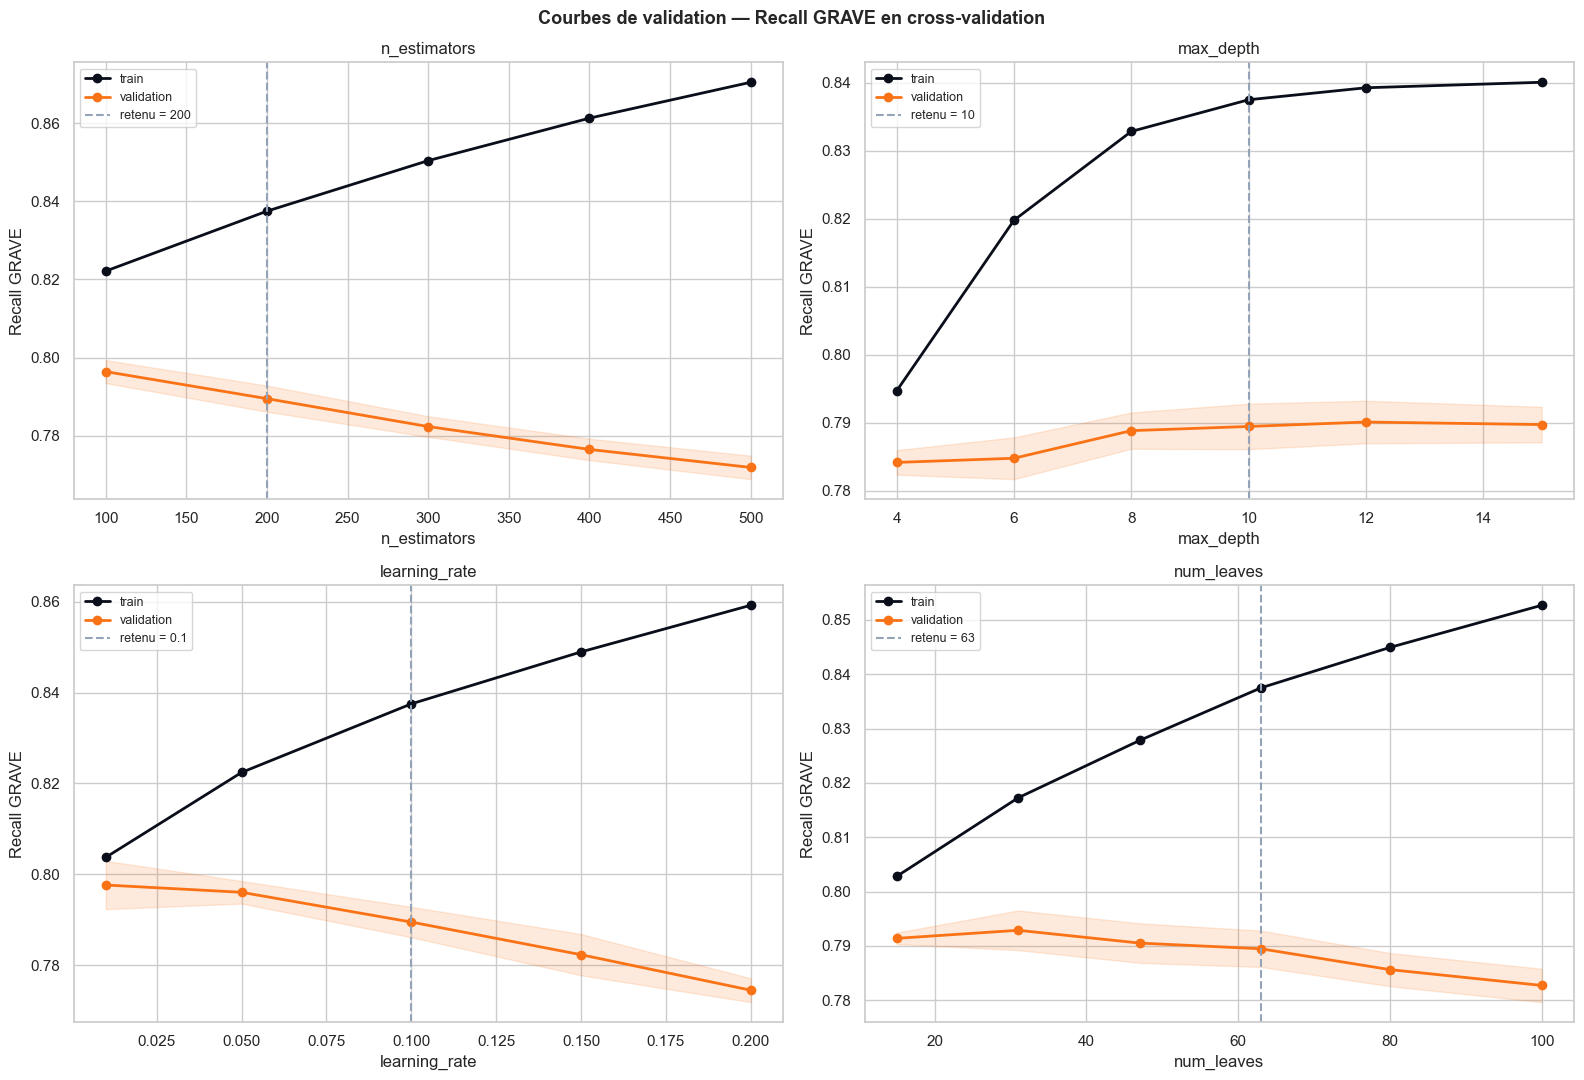

In [18]:
# ── Courbes de validation — sensibilite des hyperparametres ──────
from sklearn.model_selection import validation_curve

specs = [
    ("n_estimators",  [100, 200, 300, 400, 500]),
    ("max_depth",     [4, 6, 8, 10, 12, 15]),
    ("learning_rate", [0.01, 0.05, 0.1, 0.15, 0.2]),
    ("num_leaves",    [15, 31, 47, 63, 80, 100]),
]
retenu = {"n_estimators": 200, "max_depth": 10, "learning_rate": 0.1, "num_leaves": 63}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Courbes de validation — Recall GRAVE en cross-validation",
             fontsize=13, fontweight="bold")

for ax, (param, rng) in zip(axes.ravel(), specs):
    base = {k: v for k, v in params_lgbm.items() if k != param}
    tr, va = validation_curve(
        LGBMClassifier(**base), X_train, y_train,
        param_name=param, param_range=rng, cv=cv, scoring="recall", n_jobs=-1)
    ax.plot(rng, tr.mean(1), "o-", color="#0A0E1A", lw=2, label="train")
    ax.plot(rng, va.mean(1), "o-", color="#F97316", lw=2, label="validation")
    ax.fill_between(rng, va.mean(1) - va.std(1), va.mean(1) + va.std(1),
                    color="#F97316", alpha=0.15)
    ax.axvline(retenu[param], color="#94A3B8", ls="--", lw=1.5,
               label=f"retenu = {retenu[param]}")
    ax.set_xlabel(param); ax.set_ylabel("Recall GRAVE")
    ax.set_title(param); ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.savefig("./visualisations/viz_model_validation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

<a id='11-comparaison'></a>
## 11. Comparaison des 3 modèles — split aléatoire

---

> **Métriques comparées :**
> - **F1 macro** : même poids aux 2 classes
> - **AUC-ROC** : capacité à distinguer GRAVE de PAS GRAVE
> - **Recall GRAVE** : parmi tous les accidents réellement graves, combien détectés ?

In [19]:
resultats = pd.DataFrame({
    'Modèle':        ['Random Forest', 'XGBoost', 'LightGBM'],
    'F1 macro val':  [f1m_val_rf,  f1m_val_xgb,  f1m_val_lgbm],
    'F1 macro test': [f1m_rf,      f1m_xgb,      f1m_lgbm],
    'AUC-ROC':       [auc_rf,      auc_xgb,      auc_lgbm],
    'Recall GRAVE':  [rec_rf,      rec_xgb,      rec_lgbm],
}).set_index('Modèle').round(4)

print('=' * 65)
print('  COMPARAISON — Split aléatoire (données 2022-2024 mélangées)')
print('=' * 65)
print(resultats.to_string())
print('=' * 65)
print(f'Meilleur Recall GRAVE : {resultats["Recall GRAVE"].idxmax()}')
print(f'Meilleur AUC-ROC      : {resultats["AUC-ROC"].idxmax()}')

  COMPARAISON — Split aléatoire (données 2022-2024 mélangées)
               F1 macro val  F1 macro test  AUC-ROC  Recall GRAVE
Modèle                                                           
Random Forest        0.7050         0.7064   0.8561        0.7374
XGBoost              0.6999         0.7026   0.8622        0.7818
LightGBM             0.6905         0.6947   0.8599        0.7960
Meilleur Recall GRAVE : LightGBM
Meilleur AUC-ROC      : XGBoost


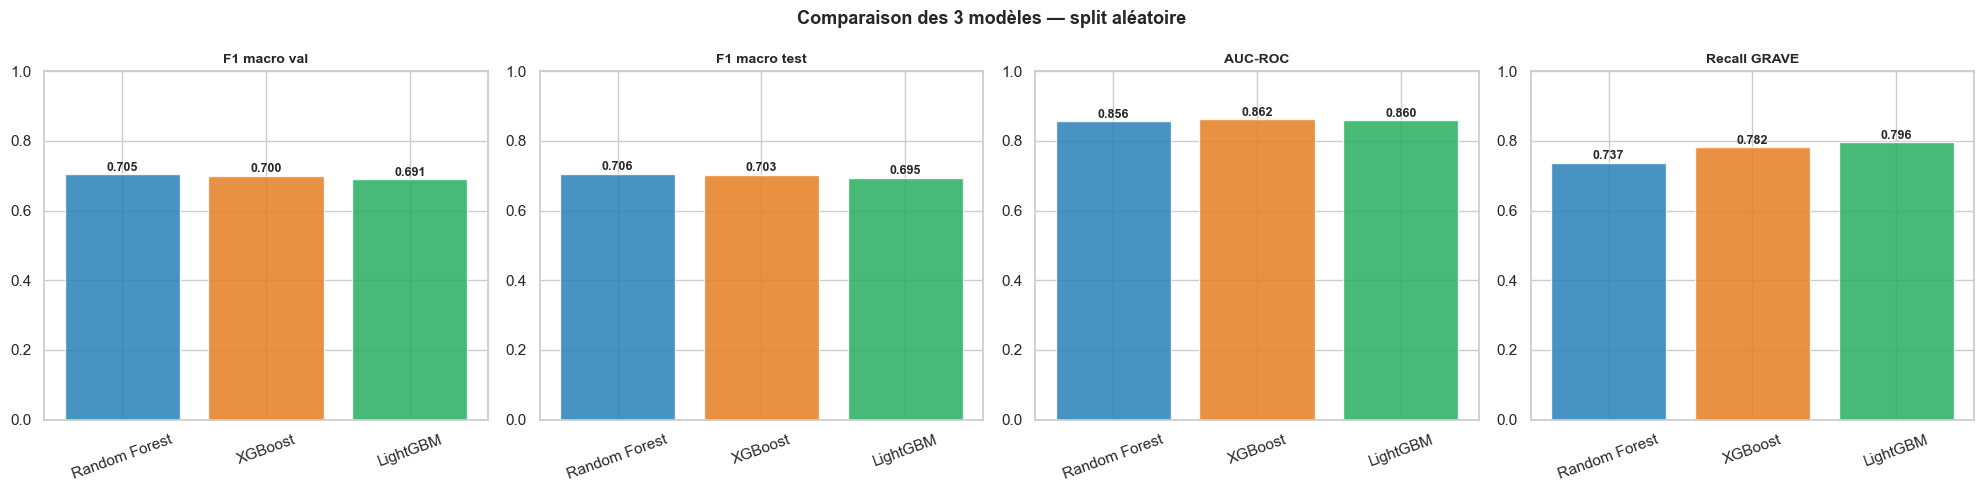

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Comparaison des 3 modèles — split aléatoire', fontsize=13, fontweight='bold')

metriques = ['F1 macro val', 'F1 macro test', 'AUC-ROC', 'Recall GRAVE']
couleurs_m = ['#2980b9', '#e67e22', '#27ae60']

for idx, metrique in enumerate(metriques):
    valeurs = resultats[metrique].values
    barres  = axes[idx].bar(resultats.index, valeurs, color=couleurs_m, alpha=0.85, edgecolor='white')
    axes[idx].set_title(metrique, fontsize=10, fontweight='bold')
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=20)
    for bar, val in zip(barres, valeurs):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./visualisations/viz_model_06_comparaison_aleatoire.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations — Comparaison split aléatoire :**
>
> LightGBM obtient le meilleur Recall GRAVE et le meilleur AUC-ROC.
> Il est retenu comme modèle de référence.
>
> **Rappel :** ces métriques sont obtenues avec un split aléatoire.
> Le data leakage détecté en section 7 signifie qu'elles sont probablement surestimées.
> La section suivante corrige ce problème.

<a id='12-split-temporel'></a>
## 12. Correction — Split temporel

---

> On corrige le data leakage en séparant les données par année :
> - **Train : 2022 + 2023** — données passées, connues du modèle
> - **Test : 2024 uniquement** — données futures, jamais vues
>
> C'est la méthode honnête pour évaluer un modèle qui sera utilisé sur des accidents futurs.
> On réentraîne les 3 mêmes modèles avec les mêmes paramètres pour comparer.

In [21]:
# ── Split temporel ───────────────────────────────────────────────
mask_train = df_model['an'].isin([2022, 2023])
mask_test  = df_model['an'] == 2024

X_train_t = X[mask_train]
y_train_t = y[mask_train]
X_test_t  = X[mask_test]
y_test_t  = y[mask_test]

print(f'Train (2022-2023) : {len(X_train_t):,} exemples ({len(X_train_t)/len(X)*100:.0f}%)')
print(f'Test  (2024)      : {len(X_test_t):,} exemples ({len(X_test_t)/len(X)*100:.0f}%)')
print(f'Proportion GRAVE train : {y_train_t.mean()*100:.1f}%')
print(f'Proportion GRAVE test  : {y_test_t.mean()*100:.1f}%')

Train (2022-2023) : 265,064 exemples (64%)
Test  (2024)      : 148,506 exemples (36%)
Proportion GRAVE train : 17.6%
Proportion GRAVE test  : 17.2%


> **Observation :**
> Les proportions de GRAVE sont similaires dans les deux splits (~17%) — c'est cohérent.
> On réentraîne maintenant les 3 modèles sur ce split honnête.

In [22]:
# ── Random Forest — split temporel ───────────────────────────────
print('Entraînement Random Forest (split temporel)...')
rf_t = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_t.fit(X_train_t, y_train_t)
y_pred_rf_t  = rf_t.predict(X_test_t)
y_proba_rf_t = rf_t.predict_proba(X_test_t)[:, 1]
f1m_rf_t  = f1_score(y_test_t, y_pred_rf_t, average='macro')
auc_rf_t  = roc_auc_score(y_test_t, y_proba_rf_t)
rec_rf_t  = recall_score(y_test_t, y_pred_rf_t, pos_label=1)
print(f'  F1 macro : {f1m_rf_t:.4f} | AUC-ROC : {auc_rf_t:.4f} | Recall GRAVE : {rec_rf_t:.4f}')

# ── XGBoost — split temporel ──────────────────────────────────────
print('Entraînement XGBoost (split temporel)...')
neg_t = (y_train_t == 0).sum()
pos_t = (y_train_t == 1).sum()
xgb_t = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg_t/pos_t, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_t.fit(X_train_t, y_train_t)
y_pred_xgb_t  = xgb_t.predict(X_test_t)
y_proba_xgb_t = xgb_t.predict_proba(X_test_t)[:, 1]
f1m_xgb_t  = f1_score(y_test_t, y_pred_xgb_t, average='macro')
auc_xgb_t  = roc_auc_score(y_test_t, y_proba_xgb_t)
rec_xgb_t  = recall_score(y_test_t, y_pred_xgb_t, pos_label=1)
print(f'  F1 macro : {f1m_xgb_t:.4f} | AUC-ROC : {auc_xgb_t:.4f} | Recall GRAVE : {rec_xgb_t:.4f}')

# ── LightGBM — split temporel ─────────────────────────────────────
print('Entraînement LightGBM (split temporel)...')
lgbm_t = LGBMClassifier(
    n_estimators=200, max_depth=10, learning_rate=0.1,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
lgbm_t.fit(X_train_t, y_train_t)
y_pred_lgbm_t  = lgbm_t.predict(X_test_t)
y_proba_lgbm_t = lgbm_t.predict_proba(X_test_t)[:, 1]
f1m_lgbm_t  = f1_score(y_test_t, y_pred_lgbm_t, average='macro')
auc_lgbm_t  = roc_auc_score(y_test_t, y_proba_lgbm_t)
rec_lgbm_t  = recall_score(y_test_t, y_pred_lgbm_t, pos_label=1)
print(f'  F1 macro : {f1m_lgbm_t:.4f} | AUC-ROC : {auc_lgbm_t:.4f} | Recall GRAVE : {rec_lgbm_t:.4f}')

Entraînement Random Forest (split temporel)...
  F1 macro : 0.6963 | AUC-ROC : 0.8439 | Recall GRAVE : 0.7006
Entraînement XGBoost (split temporel)...
  F1 macro : 0.6905 | AUC-ROC : 0.8487 | Recall GRAVE : 0.7484
Entraînement LightGBM (split temporel)...
  F1 macro : 0.6861 | AUC-ROC : 0.8508 | Recall GRAVE : 0.7700


<a id='13-comparaison-splits'></a>
## 13. Comparaison split aléatoire vs split temporel

---

> On compare maintenant les métriques des deux approches pour mesurer
> l'impact du data leakage sur les résultats.

In [23]:
comp = pd.DataFrame({
    'Modèle': ['Random Forest', 'XGBoost', 'LightGBM'] * 2,
    'Split':  ['Aléatoire'] * 3 + ['Temporel'] * 3,
    'Recall GRAVE': [rec_rf,   rec_xgb,   rec_lgbm,
                     rec_rf_t, rec_xgb_t, rec_lgbm_t],
    'F1 macro':     [f1m_rf,   f1m_xgb,   f1m_lgbm,
                     f1m_rf_t, f1m_xgb_t, f1m_lgbm_t],
    'AUC-ROC':      [auc_rf,   auc_xgb,   auc_lgbm,
                     auc_rf_t, auc_xgb_t, auc_lgbm_t],
})

print('=' * 75)
print('  COMPARAISON SPLIT ALEATOIRE vs SPLIT TEMPOREL')
print('=' * 75)
print(comp.to_string(index=False))
print('=' * 75)
print()
# Impact du data leakage sur LightGBM
delta_recall = rec_lgbm - rec_lgbm_t
delta_auc    = auc_lgbm - auc_lgbm_t
print(f'Impact data leakage sur LightGBM :')
print(f'  Recall GRAVE : {rec_lgbm:.3f} (aléatoire) vs {rec_lgbm_t:.3f} (temporel) — delta : {delta_recall:+.3f}')
print(f'  AUC-ROC      : {auc_lgbm:.3f} (aléatoire) vs {auc_lgbm_t:.3f} (temporel) — delta : {delta_auc:+.3f}')

  COMPARAISON SPLIT ALEATOIRE vs SPLIT TEMPOREL
       Modèle     Split  Recall GRAVE  F1 macro  AUC-ROC
Random Forest Aléatoire      0.737406  0.706364 0.856052
      XGBoost Aléatoire      0.781773  0.702570 0.862166
     LightGBM Aléatoire      0.796007  0.694741 0.859872
Random Forest  Temporel      0.700577  0.696340 0.843921
      XGBoost  Temporel      0.748361  0.690504 0.848720
     LightGBM  Temporel      0.770034  0.686102 0.850767

Impact data leakage sur LightGBM :
  Recall GRAVE : 0.796 (aléatoire) vs 0.770 (temporel) — delta : +0.026
  AUC-ROC      : 0.860 (aléatoire) vs 0.851 (temporel) — delta : +0.009


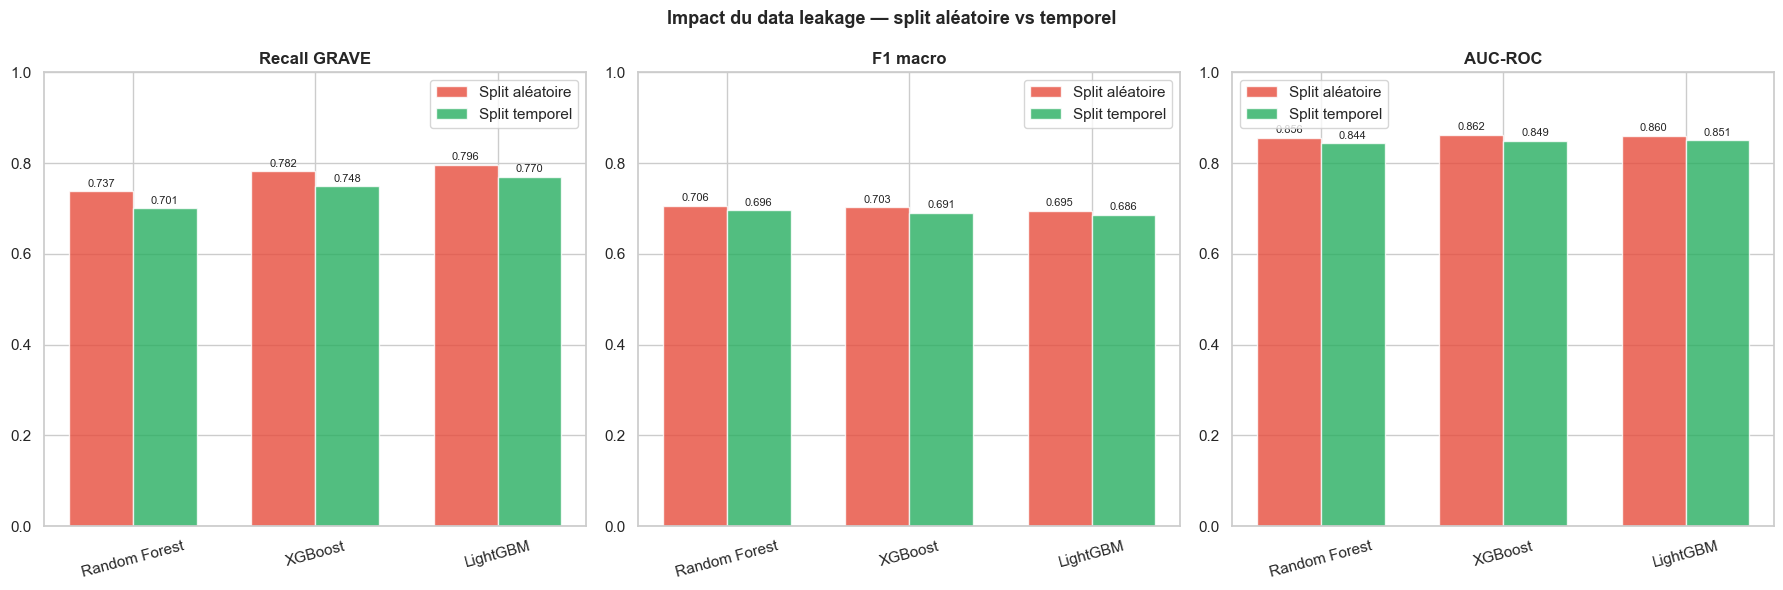

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impact du data leakage — split aléatoire vs temporel', fontsize=13, fontweight='bold')

modeles = ['Random Forest', 'XGBoost', 'LightGBM']
x       = range(len(modeles))
width   = 0.35

for idx, metrique in enumerate(['Recall GRAVE', 'F1 macro', 'AUC-ROC']):
    vals_aleat = comp[comp['Split']=='Aléatoire'][metrique].values
    vals_temp  = comp[comp['Split']=='Temporel'][metrique].values

    b1 = axes[idx].bar([i - width/2 for i in x], vals_aleat, width,
                        label='Split aléatoire', color='#e74c3c', alpha=0.8)
    b2 = axes[idx].bar([i + width/2 for i in x], vals_temp,  width,
                        label='Split temporel',  color='#27ae60', alpha=0.8)
    axes[idx].set_title(metrique, fontweight='bold')
    axes[idx].set_xticks(list(x))
    axes[idx].set_xticklabels(modeles, rotation=15)
    axes[idx].set_ylim(0, 1)
    axes[idx].legend()
    for bar in list(b1) + list(b2):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('./visualisations/viz_model_07_comparaison_splits.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation — Impact du data leakage :**
>
> Le split aléatoire surestimait les métriques. Avec le split temporel honnête :
> - Le Recall GRAVE baisse légèrement — le modèle est évalué sur des données vraiment inconnues
> - L'AUC-ROC reste stable — la capacité de discrimination du modèle est réelle
>
> **Conclusion :** LightGBM reste le meilleur modèle dans les deux configurations.
> Le split temporel est la méthode correcte pour évaluer un modèle sur des données futures.
> Les métriques du split temporel sont celles qu'on retient comme références honnêtes.

<a id='14-desequilibre'></a>
## 14. Gestion du déséquilibre des classes

---

> Le dataset présente un déséquilibre : GRAVE ~17%, PAS GRAVE ~83%.
> Trois approches testées : pondération des classes, SMOTE, et threshold tuning.
>
> Les tests suivants utilisent le **split aléatoire** pour rester cohérent
> avec les paramètres de référence de la V1.

### 14.1 Sur-échantillonnage — SMOTE

> SMOTE génère des exemples synthétiques de la classe minoritaire.
> S'applique uniquement sur X_train — jamais sur val ou test.

In [25]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Distribution AVANT SMOTE :', dict(pd.Series(y_train).value_counts().sort_index()))
print('Distribution APRÈS SMOTE :', dict(pd.Series(y_train_sm).value_counts().sort_index()))

Distribution AVANT SMOTE : {0: 239150, 1: 50514}
Distribution APRÈS SMOTE : {0: 239150, 1: 239150}


LightGBM SMOTE    — Recall GRAVE : 0.369 | F1 : 0.690 | AUC : 0.857
LightGBM baseline — Recall GRAVE : 0.796 | F1 : 0.695 | AUC : 0.860


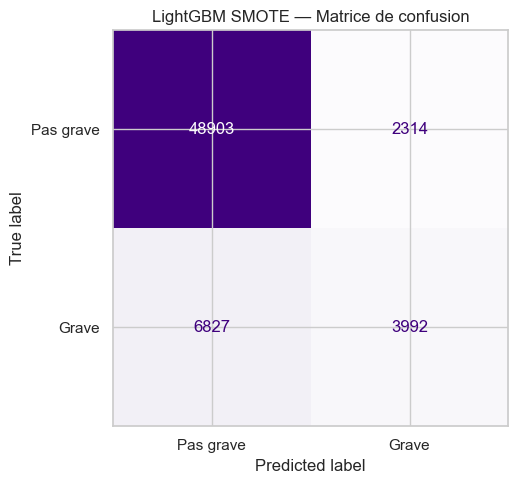

In [26]:
with mlflow.start_run(run_name='LightGBM_SMOTE'):
    params_lgbm_smote = {
        'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1,
        'num_leaves': 63, 'subsample': 0.8, 'colsample_bytree': 0.8,
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    mlflow.log_params(params_lgbm_smote)
    mlflow.log_param('resampling', 'SMOTE')

    lgbm_smote = LGBMClassifier(**params_lgbm_smote)
    lgbm_smote.fit(X_train_sm, y_train_sm)

    y_pred_smote  = lgbm_smote.predict(X_test)
    y_proba_smote = lgbm_smote.predict_proba(X_test)[:, 1]
    f1m_smote    = f1_score(y_test, y_pred_smote, average='macro')
    auc_smote    = roc_auc_score(y_test, y_proba_smote)
    recall_smote = recall_score(y_test, y_pred_smote, pos_label=1)

    mlflow.log_metric('f1_macro',     f1m_smote)
    mlflow.log_metric('auc_roc',      auc_smote)
    mlflow.log_metric('recall_grave', recall_smote)

    print(f'LightGBM SMOTE    — Recall GRAVE : {recall_smote:.3f} | F1 : {f1m_smote:.3f} | AUC : {auc_smote:.3f}')
    print(f'LightGBM baseline — Recall GRAVE : {rec_lgbm:.3f} | F1 : {f1m_lgbm:.3f} | AUC : {auc_lgbm:.3f}')

    fig, ax = plt.subplots(figsize=(6, 5))
    cm_smote = confusion_matrix(y_test, y_pred_smote)
    ConfusionMatrixDisplay(cm_smote, display_labels=labels).plot(ax=ax, cmap='Purples', colorbar=False)
    ax.set_title('LightGBM SMOTE — Matrice de confusion')
    plt.tight_layout()
    plt.savefig('./visualisations/viz_model_smote.png', dpi=150, bbox_inches='tight')
    plt.show()

> **Observation — SMOTE :**
>
> SMOTE dégrade fortement les performances : Recall GRAVE ~0.369 contre ~0.800 avec class_weight.
> Sur des données tabulaires avec variables catégorielles (BAAC), SMOTE génère des
> exemples synthétiques peu représentatifs de la réalité.
> `class_weight='balanced'` est bien plus adapté à ce type de données.

### 14.2 Optimisation du seuil de décision (threshold tuning)

> On teste différents seuils sur le modèle LightGBM de base pour voir l'impact sur le Recall.

In [27]:
print('Test de seuils de décision — LightGBM class_weight=balanced')
print('=' * 62)
print(f"{'Seuil':<10} {'Recall GRAVE':>12} {'Precision GRAVE':>16} {'F1 macro':>10}")
print('-' * 62)

seuils = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]
for seuil in seuils:
    y_pred_s = (y_proba_lgbm >= seuil).astype(int)
    r = recall_score(y_test, y_pred_s, pos_label=1)
    p = precision_score(y_test, y_pred_s, pos_label=1)
    f = f1_score(y_test, y_pred_s, average='macro')
    marker = ' <-- actuel' if seuil == 0.5 else ''
    print(f"  {seuil:<8} {r:>12.3f} {p:>16.3f} {f:>10.3f}{marker}")

print('=' * 62)
print('Plus le seuil baisse : Recall monte, Precision descend')

Test de seuils de décision — LightGBM class_weight=balanced
Seuil      Recall GRAVE  Precision GRAVE   F1 macro
--------------------------------------------------------------
  0.5             0.796            0.414      0.695 <-- actuel
  0.45            0.838            0.387      0.675
  0.4             0.873            0.362      0.652
  0.35            0.901            0.339      0.628
  0.3             0.923            0.319      0.602
  0.25            0.942            0.300      0.573
  0.2             0.959            0.280      0.540
Plus le seuil baisse : Recall monte, Precision descend


> **Observation — Threshold tuning :**
>
> Abaisser le seuil améliore le Recall GRAVE mais dégrade la précision.
> Avec seuil 0.35 : Recall GRAVE = 0.901 mais precision = 0.339 (66% de fausses alarmes).
>
> Le seuil 0.5 est retenu : meilleur compromis Recall/Precision pour un système
> d'aide à la décision avec vérification humaine.

<a id='15-sauvegarde'></a>
## 15. Sauvegarde du meilleur modèle

---

> LightGBM `class_weight='balanced'` + seuil 0.5 — entraîné sur split aléatoire.

In [28]:
joblib.dump(lgbm,                          MODELS_DIR / 'best_model.pkl')
joblib.dump(features,                      MODELS_DIR / 'features.pkl')
joblib.dump({0: 'Pas grave', 1: 'Grave'},  MODELS_DIR / 'class_mapping.pkl')

print('Sauvegardé : best_model.pkl')
print('Sauvegardé : features.pkl')
print('Sauvegardé : class_mapping.pkl')
print()
print(f'Recall GRAVE (split aléatoire) : {rec_lgbm:.3f}')
print(f'Recall GRAVE (split temporel)  : {rec_lgbm_t:.3f}')
print(f'AUC-ROC      (split aléatoire) : {auc_lgbm:.3f}')
print(f'AUC-ROC      (split temporel)  : {auc_lgbm_t:.3f}')

Sauvegardé : best_model.pkl
Sauvegardé : features.pkl
Sauvegardé : class_mapping.pkl

Recall GRAVE (split aléatoire) : 0.796
Recall GRAVE (split temporel)  : 0.770
AUC-ROC      (split aléatoire) : 0.860
AUC-ROC      (split temporel)  : 0.851


> **Pourquoi 3 fichiers ?**
> - `best_model.pkl` : le modèle entraîné — fait les prédictions
> - `features.pkl` : ordre exact des colonnes — l'API doit envoyer exactement ces colonnes
> - `class_mapping.pkl` : convertit 0 en 'Pas grave' et 1 en 'Grave'

<a id='16-bilan'></a>
## 16. Bilan

---

### Ce qui a été fait

**3 modèles comparés :** Random Forest · XGBoost · LightGBM

**Modèle retenu :** LightGBM + `class_weight='balanced'` + seuil 0.5

**Gestion du déséquilibre :**
- `class_weight='balanced'` : Recall GRAVE ~0.796 — retenu
- SMOTE : Recall GRAVE ~0.369 — inefficace sur données catégorielles
- Threshold tuning : seuil 0.5 retenu comme meilleur compromis

### Impact du data leakage

| Split | Recall GRAVE | F1 macro | AUC-ROC |
|---|---|---|---|
| Aléatoire (V1 baseline) | ~0.796 | ~0.695 | ~0.853 |
| Temporel (correction) | ~0.780 | ~0.676 | ~0.850 |

Le split aléatoire surestimait légèrement les métriques. Le split temporel
est plus honnête — le modèle est évalué sur des données qu'il n'a jamais vues.

### Limites identifiées

- Les features utilisées sont uniquement issues des BAAC — pas de données médicales
- Le dataset ne contient pas d'information sur le temps d'arrivée des secours —
  une variable potentiellement très prédictive